## Nombre: Anthony Goyes


# Ejercicio 10: Re-ranking

**Objetivo:** Implementar y evaluar un pipeline de Recuperación de Información en dos etapas, y analizar el impacto del re-ranking en la calidad del ranking.

## Parte 1. Preparación del corpus

* Cargar el corpus (documentos/pasajes).
* Cargar las consultas (queries).
* Cargar qrels (relevancia).

In [1]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader
import pandas as pd

C:\Users\Anthony\AppData\Roaming\Python\Python313\site-packages\beir\util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
DATASET_NAME = "scifact"
DATA_DIR = "../data/beir_datasets"
url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{DATASET_NAME}.zip"
util.download_and_unzip(url, DATA_DIR)

../data/beir_datasets\scifact.zip:   0%|          | 0.00/2.69M [00:00<?, ?iB/s]

'../data/beir_datasets\\scifact'

In [3]:
dataset_path = DATA_DIR + "/" + DATASET_NAME
corpus, queries, qrels = GenericDataLoader(dataset_path).load(split="test")

  0%|          | 0/5183 [00:00<?, ?it/s]

In [4]:
df_corpus = (
    pd.DataFrame.from_dict(corpus, orient="index")
      .reset_index()
      .rename(columns={"index": "doc_id"})
)

df_corpus

,doc_id,text,title
0,4983,Alterations of the architecture of cerebral wh...,Microstructural development of human newborn c...
1,5836,Myelodysplastic syndromes (MDS) are age-depend...,Induction of myelodysplasia by myeloid-derived...
2,7912,ID elements are short interspersed elements (S...,"BC1 RNA, the transcript from a master gene for..."
3,18670,DNA methylation plays an important role in bio...,The DNA Methylome of Human Peripheral Blood Mo...
4,19238,Two human Golli (for gene expressed in the oli...,The human myelin basic protein gene is include...
...,...,...,...
5178,195689316,BACKGROUND The main associations of body-mass ...,Body-mass index and cause-specific mortality i...
5179,195689757,A key aberrant biological difference between t...,Targeting metabolic remodeling in glioblastoma...
5180,196664003,A signaling pathway transmits information from...,Signaling architectures that transmit unidirec...
5181,198133135,AIMS Trabecular bone score (TBS) is a surrogat...,"Association between pre-diabetes, type 2 diabe..."


In [5]:
df_queries = (
    pd.DataFrame.from_dict(queries, orient="index", columns=["query"])
      .reset_index()
      .rename(columns={"index": "query_id"})
)

df_queries

,query_id,query
0,1,0-dimensional biomaterials show inductive prop...
1,3,"1,000 genomes project enables mapping of genet..."
2,5,1/2000 in UK have abnormal PrP positivity.
3,13,5% of perinatal mortality is due to low birth ...
4,36,A deficiency of vitamin B12 increases blood le...
...,...,...
295,1379,Women with a higher birth weight are more like...
296,1382,aPKCz causes tumour enhancement by affecting g...
297,1385,cSMAC formation enhances weak ligand signalling.
298,1389,mTORC2 regulates intracellular cysteine levels...


In [6]:
rows = []
for qid, docs in qrels.items():
    for doc_id, rel in docs.items():
        rows.append({
            "query_id": qid,
            "doc_id": doc_id,
            "relevance": rel
        })

df_qrels = pd.DataFrame(rows)
df_qrels

,query_id,doc_id,relevance
0,1,31715818,1
1,3,14717500,1
2,5,13734012,1
3,13,1606628,1
4,36,5152028,1
...,...,...,...
334,1379,17450673,1
335,1382,17755060,1
336,1385,306006,1
337,1389,23895668,1


In [7]:
# Elegimos una query cualquiera que tenga varios documentos relevantes
qid = "133"

print("Query:")
print(df_queries.loc[df_queries["query_id"] == qid, "query"].values[0])

print("\nDocumentos relevantes para esta query:")
df_qrels[(df_qrels["query_id"] == qid) & (df_qrels["relevance"] > 0)]

Query:
Assembly of invadopodia is triggered by focal generation of phosphatidylinositol-3,4-biphosphate and the activation of the nonreceptor tyrosine kinase Src.

Documentos relevantes para esta query:


,query_id,doc_id,relevance
31,133,38485364,1
32,133,6969753,1
33,133,17934082,1
34,133,16280642,1
35,133,12640810,1


## Parte 2. Retrieval inicial (baseline)

* Implementar retrieval inicial con BM25
* Obtener métricas: Recall@10 nDCG@10

### Importar y crear función de tokenización

In [8]:
import re
import numpy as np
from rank_bm25 import BM25Okapi

def tokenize(text):
    text = text.lower()
    return re.findall(r"\b\w+\b", text)

### Preparar los documentos del corpus

In [9]:
doc_ids = list(corpus.keys())

doc_texts = [
    corpus[doc_id].get("title", "") + " " + corpus[doc_id].get("text", "")
    for doc_id in doc_ids
]

tokenized_corpus = [tokenize(text) for text in doc_texts]

bm25 = BM25Okapi(tokenized_corpus)

print("BM25 preparado con", len(doc_ids), "documentos")

BM25 preparado con 5183 documentos


### Recuperar documentos con BM25

In [10]:
TOP_K = 100

bm25_results = {}

for qid, query in queries.items():
    tokenized_query = tokenize(query)
    scores = bm25.get_scores(tokenized_query)
    
    top_indices = np.argsort(scores)[::-1][:TOP_K]
    
    bm25_results[qid] = {
        doc_ids[i]: float(scores[i])
        for i in top_indices
    }

print("Retrieval BM25 terminado para", len(bm25_results), "queries")

Retrieval BM25 terminado para 300 queries


### Revisar resultados de BM25 para la query 133

In [11]:
qid = "133"

top_docs = list(bm25_results[qid].items())[:10]

rows = []

for rank, (doc_id, score) in enumerate(top_docs, start=1):
    rows.append({
        "rank": rank,
        "doc_id": doc_id,
        "bm25_score": score,
        "relevance": qrels.get(qid, {}).get(doc_id, 0),
        "title": corpus[doc_id].get("title", "")
    })

df_bm25_top10 = pd.DataFrame(rows)
df_bm25_top10

,rank,doc_id,bm25_score,relevance,title
0,1,5270265,54.370321,0,Combating trastuzumab resistance by targeting ...
1,2,26688294,53.982786,0,Schizophrenia susceptibility pathway neureguli...
2,3,19752008,53.680652,0,A specific inhibitor of phosphatidylinositol 3...
3,4,45764440,52.902112,0,Inhibition of SRC expression and activity inhi...
4,5,16280642,52.480827,1,Sequential signals toward podosome formation i...
5,6,12785130,51.389244,0,The regulation of N-methyl-D-aspartate recepto...
6,7,5914739,50.409446,0,Local changes in lipid environment of TCR micr...
7,8,11200685,49.134093,0,Integrins regulate microtubule nucleating acti...
8,9,37964706,48.742054,0,Local Ca2+ influx through Ca2+ release-activat...
9,10,35660758,48.502792,0,D3 phosphoinositides and outside-in integrin s...


### Funciones de evaluación

In [12]:
import math

def dcg_at_k(relevances, k):
    relevances = relevances[:k]
    
    dcg = 0.0
    
    for i, rel in enumerate(relevances):
        dcg += (2**rel - 1) / math.log2(i + 2)
    
    return dcg


def ndcg_at_k(qrels_qid, ranked_docs, k=10):
    relevances = [
        qrels_qid.get(doc_id, 0)
        for doc_id in ranked_docs[:k]
    ]
    
    ideal_relevances = sorted(qrels_qid.values(), reverse=True)
    
    dcg = dcg_at_k(relevances, k)
    idcg = dcg_at_k(ideal_relevances, k)
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg


def recall_at_k(qrels_qid, ranked_docs, k=10):
    relevant_docs = {
        doc_id
        for doc_id, rel in qrels_qid.items()
        if rel > 0
    }
    
    if len(relevant_docs) == 0:
        return 0.0
    
    retrieved_docs = set(ranked_docs[:k])
    
    return len(relevant_docs.intersection(retrieved_docs)) / len(relevant_docs)


def evaluate_run(qrels, run, k=10):
    ndcg_scores = []
    recall_scores = []
    
    for qid in qrels:
        if qid not in run:
            continue
        
        ranked_docs = list(run[qid].keys())
        
        ndcg_scores.append(
            ndcg_at_k(qrels[qid], ranked_docs, k)
        )
        
        recall_scores.append(
            recall_at_k(qrels[qid], ranked_docs, k)
        )
    
    return {
        f"nDCG@{k}": np.mean(ndcg_scores),
        f"Recall@{k}": np.mean(recall_scores)
    }

### Evaluar BM25

In [13]:
bm25_metrics = evaluate_run(qrels, bm25_results, k=10)

bm25_metrics

{'nDCG@10': np.float64(0.6518925893260478),
 'Recall@10': np.float64(0.7739999999999999)}

## Parte 3. Implementación del re-ranking _cross-encoder_

* Re-rankear los top-k candidatos para cada query.
* Identificar qué documentos cambian de posición en el top 10

### Importar CrossEncoder

In [14]:
from sentence_transformers import CrossEncoder

### Cargar modelo

In [15]:
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

C:\Users\Anthony\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Anthony\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

### Crear diccionario de textos

In [16]:
doc_text_by_id = {
    doc_id: corpus[doc_id].get("title", "") + " " + corpus[doc_id].get("text", "")
    for doc_id in corpus
}

### Re-rankear candidatos BM25

In [19]:
from tqdm.notebook import tqdm

CE_TOP_K = 20

ce_results = {}

for qid, query in tqdm(queries.items(), total=len(queries)):
    candidate_doc_ids = list(bm25_results[qid].keys())[:CE_TOP_K]
    
    pairs = [
        (query, doc_text_by_id[doc_id])
        for doc_id in candidate_doc_ids
    ]
    
    ce_scores = cross_encoder.predict(
        pairs,
        batch_size=16,
        show_progress_bar=False
    )
    
    scored_docs = list(zip(candidate_doc_ids, ce_scores))
    scored_docs = sorted(scored_docs, key=lambda x: x[1], reverse=True)
    
    ce_results[qid] = {
        doc_id: float(score)
        for doc_id, score in scored_docs
    }

print("Re-ranking con Cross-Encoder terminado")

  0%|          | 0/300 [00:00<?, ?it/s]

Re-ranking con Cross-Encoder terminado


### Evaluar Cross-Encoder

In [20]:
ce_metrics = evaluate_run(qrels, ce_results, k=10)

ce_metrics

{'nDCG@10': np.float64(0.685113076792378),
 'Recall@10': np.float64(0.8022777777777778)}

### Comparar BM25 vs Cross-Encoder

In [21]:
pd.DataFrame([
    {"modelo": "BM25", **bm25_metrics},
    {"modelo": "BM25 + CrossEncoder", **ce_metrics}
])

,modelo,nDCG@10,Recall@10
0,BM25,0.651893,0.774000
1,BM25 + CrossEncoder,0.685113,0.802278


### Ver qué documentos cambiaron de posición

In [22]:
def compare_top10(before_run, after_run, qid):
    before_docs = list(before_run[qid].keys())[:10]
    after_docs = list(after_run[qid].keys())[:10]
    
    all_docs = list(dict.fromkeys(before_docs + after_docs))
    
    rows = []
    
    for doc_id in all_docs:
        before_rank = before_docs.index(doc_id) + 1 if doc_id in before_docs else None
        after_rank = after_docs.index(doc_id) + 1 if doc_id in after_docs else None
        
        rows.append({
            "doc_id": doc_id,
            "title": corpus[doc_id].get("title", ""),
            "rank_BM25": before_rank,
            "rank_CrossEncoder": after_rank,
            "relevance": qrels.get(qid, {}).get(doc_id, 0),
            "cambio": before_rank != after_rank
        })
    
    return pd.DataFrame(rows)

In [23]:
compare_top10(bm25_results, ce_results, "133")

,doc_id,title,rank_BM25,rank_CrossEncoder,relevance,cambio
0,5270265,Combating trastuzumab resistance by targeting ...,1.0,NaN,0,True
1,26688294,Schizophrenia susceptibility pathway neureguli...,2.0,NaN,0,True
2,19752008,A specific inhibitor of phosphatidylinositol 3...,3.0,6.0,0,True
3,45764440,Inhibition of SRC expression and activity inhi...,4.0,NaN,0,True
4,16280642,Sequential signals toward podosome formation i...,5.0,3.0,1,True
5,12785130,The regulation of N-methyl-D-aspartate recepto...,6.0,NaN,0,True
6,5914739,Local changes in lipid environment of TCR micr...,7.0,10.0,0,True
7,11200685,Integrins regulate microtubule nucleating acti...,8.0,NaN,0,True
8,37964706,Local Ca2+ influx through Ca2+ release-activat...,9.0,9.0,0,False
9,35660758,D3 phosphoinositides and outside-in integrin s...,10.0,1.0,0,True


## Parte 4. Implementación del re-ranking _LTR_

* Re-rankear los top-k candidatos para cada query.
* Identificar qué documentos cambian de posición en el top 10

In [25]:
DATASET_NAME = "scifact"
DATA_DIR = "../data/beir_datasets"

data_path = DATA_DIR + "/" + DATASET_NAME

data_path

'../data/beir_datasets/scifact'

### Cargar datos de entrenamiento

In [26]:
corpus_train, queries_train, qrels_train = GenericDataLoader(data_path).load(split="train")

print("Queries train:", len(queries_train))
print("Qrels train:", len(qrels_train))

  0%|          | 0/5183 [00:00<?, ?it/s]

Queries train: 809
Qrels train: 809


### Recuperar candidatos BM25 para train

In [27]:
TRAIN_TOP_K = 100

train_bm25_results = {}

for qid, query in tqdm(queries_train.items(), total=len(queries_train)):
    tokenized_query = tokenize(query)
    scores = bm25.get_scores(tokenized_query)
    
    top_indices = np.argsort(scores)[::-1][:TRAIN_TOP_K]
    
    train_bm25_results[qid] = {
        doc_ids[i]: float(scores[i])
        for i in top_indices
    }

print("Candidatos BM25 para train generados")

  0%|          | 0/809 [00:00<?, ?it/s]

Candidatos BM25 para train generados


### Crear funciones de características para LTR

In [28]:
def safe_div(a, b):
    return a / b if b != 0 else 0


def get_doc_title_text(doc_id):
    title = corpus[doc_id].get("title", "")
    text = corpus[doc_id].get("text", "")
    full_text = title + " " + text
    return title, text, full_text


def make_ltr_features(query, doc_id, bm25_score):
    title, text, full_text = get_doc_title_text(doc_id)
    
    q_tokens = tokenize(query)
    title_tokens = tokenize(title)
    text_tokens = tokenize(text)
    full_tokens = tokenize(full_text)
    
    q_set = set(q_tokens)
    title_set = set(title_tokens)
    full_set = set(full_tokens)
    
    overlap_full = len(q_set & full_set)
    overlap_title = len(q_set & title_set)
    
    return [
        bm25_score,
        len(q_tokens),
        len(title_tokens),
        len(text_tokens),
        len(full_tokens),
        overlap_full,
        overlap_title,
        safe_div(overlap_full, len(q_set)),
        safe_div(overlap_title, len(q_set))
    ]

### Construir el dataset de entrenamiento

In [29]:
X_train = []
y_train = []

for qid, candidates in tqdm(train_bm25_results.items(), total=len(train_bm25_results)):
    query = queries_train[qid]
    
    for doc_id, bm25_score in candidates.items():
        features = make_ltr_features(query, doc_id, bm25_score)
        label = qrels_train.get(qid, {}).get(doc_id, 0)
        
        X_train.append(features)
        y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("Relevantes en train:", np.sum(y_train > 0))

  0%|          | 0/809 [00:00<?, ?it/s]

X_train: (80900, 9)
y_train: (80900,)
Relevantes en train: 831


### Entrenar modelo LTR

In [30]:
from sklearn.ensemble import RandomForestClassifier

ltr_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

ltr_model.fit(X_train, y_train)

print("Modelo LTR entrenado")

Modelo LTR entrenado


### Aplicar LTR sobre los candidatos BM25 de test

In [31]:
ltr_results = {}

for qid, candidates in tqdm(bm25_results.items(), total=len(bm25_results)):
    query = queries[qid]
    candidate_doc_ids = list(candidates.keys())
    
    X_test = []
    
    for doc_id in candidate_doc_ids:
        bm25_score = candidates[doc_id]
        features = make_ltr_features(query, doc_id, bm25_score)
        X_test.append(features)
    
    X_test = np.array(X_test)
    
    # Probabilidad de que el documento sea relevante
    ltr_scores = ltr_model.predict_proba(X_test)[:, 1]
    
    scored_docs = list(zip(candidate_doc_ids, ltr_scores))
    scored_docs = sorted(scored_docs, key=lambda x: x[1], reverse=True)
    
    ltr_results[qid] = {
        doc_id: float(score)
        for doc_id, score in scored_docs
    }

print("Re-ranking LTR terminado")

  0%|          | 0/300 [00:00<?, ?it/s]

Re-ranking LTR terminado


### Evaluar LTR

In [33]:
import numpy as np
import math

def dcg_at_k(relevances, k):
    relevances = relevances[:k]
    
    dcg = 0.0
    
    for i, rel in enumerate(relevances):
        dcg += (2**rel - 1) / math.log2(i + 2)
    
    return dcg


def ndcg_at_k(qrels_qid, ranked_docs, k=10):
    relevances = [
        qrels_qid.get(doc_id, 0)
        for doc_id in ranked_docs[:k]
    ]
    
    ideal_relevances = sorted(qrels_qid.values(), reverse=True)
    
    dcg = dcg_at_k(relevances, k)
    idcg = dcg_at_k(ideal_relevances, k)
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg


def recall_at_k(qrels_qid, ranked_docs, k=10):
    relevant_docs = {
        doc_id
        for doc_id, rel in qrels_qid.items()
        if rel > 0
    }
    
    if len(relevant_docs) == 0:
        return 0.0
    
    retrieved_docs = set(ranked_docs[:k])
    
    return len(relevant_docs.intersection(retrieved_docs)) / len(relevant_docs)


def average_precision(qrels_qid, ranked_docs):
    relevant_docs = {
        doc_id
        for doc_id, rel in qrels_qid.items()
        if rel > 0
    }
    
    if len(relevant_docs) == 0:
        return 0.0
    
    hits = 0
    precision_sum = 0.0
    
    for idx, doc_id in enumerate(ranked_docs, start=1):
        if doc_id in relevant_docs:
            hits += 1
            precision_sum += hits / idx
    
    return precision_sum / len(relevant_docs)


def evaluate_run_full(qrels, run, k=10):
    ndcg_scores = []
    recall_scores = []
    ap_scores = []
    
    for qid in qrels:
        if qid not in run:
            continue
        
        ranked_docs = list(run[qid].keys())
        
        ndcg_scores.append(ndcg_at_k(qrels[qid], ranked_docs, k))
        recall_scores.append(recall_at_k(qrels[qid], ranked_docs, k))
        ap_scores.append(average_precision(qrels[qid], ranked_docs))
    
    return {
        f"nDCG@{k}": np.mean(ndcg_scores),
        f"Recall@{k}": np.mean(recall_scores),
        "MAP": np.mean(ap_scores)
    }

In [34]:
ltr_metrics_full = evaluate_run_full(qrels, ltr_results, k=10)

ltr_metrics_full

{'nDCG@10': np.float64(0.6784342476816327),
 'Recall@10': np.float64(0.7723333333333333),
 'MAP': np.float64(0.6494582537186975)}

### Comparar BM25, Cross-Encoder y LTR

In [36]:
bm25_metrics_full = evaluate_run_full(qrels, bm25_results, k=10)
ce_metrics_full = evaluate_run_full(qrels, ce_results, k=10)
ltr_metrics_full = evaluate_run_full(qrels, ltr_results, k=10)

In [37]:
final_results = pd.DataFrame([
    {"modelo": "BM25", **bm25_metrics_full},
    {"modelo": "BM25 + CrossEncoder", **ce_metrics_full},
    {"modelo": "BM25 + LTR", **ltr_metrics_full}
])

final_results

,modelo,nDCG@10,Recall@10,MAP
0,BM25,0.651893,0.774000,0.613182
1,BM25 + CrossEncoder,0.685113,0.802278,0.643195
2,BM25 + LTR,0.678434,0.772333,0.649458


### Identificar cambios de posición en top 10 con LTR

In [38]:
def compare_top10_general(before_run, after_run, qid, after_name="LTR"):
    before_docs = list(before_run[qid].keys())[:10]
    after_docs = list(after_run[qid].keys())[:10]
    
    all_docs = list(dict.fromkeys(before_docs + after_docs))
    
    rows = []
    
    for doc_id in all_docs:
        before_rank = before_docs.index(doc_id) + 1 if doc_id in before_docs else None
        after_rank = after_docs.index(doc_id) + 1 if doc_id in after_docs else None
        
        rows.append({
            "doc_id": doc_id,
            "title": corpus[doc_id].get("title", ""),
            "rank_BM25": before_rank,
            f"rank_{after_name}": after_rank,
            "relevance": qrels.get(qid, {}).get(doc_id, 0),
            "cambio": before_rank != after_rank
        })
    
    return pd.DataFrame(rows)

In [39]:
compare_top10_general(bm25_results, ltr_results, "133", after_name="LTR")

,doc_id,title,rank_BM25,rank_LTR,relevance,cambio
0,5270265,Combating trastuzumab resistance by targeting ...,1.0,9.0,0,True
1,26688294,Schizophrenia susceptibility pathway neureguli...,2.0,6.0,0,True
2,19752008,A specific inhibitor of phosphatidylinositol 3...,3.0,1.0,0,True
3,45764440,Inhibition of SRC expression and activity inhi...,4.0,NaN,0,True
4,16280642,Sequential signals toward podosome formation i...,5.0,7.0,1,True
5,12785130,The regulation of N-methyl-D-aspartate recepto...,6.0,2.0,0,True
6,5914739,Local changes in lipid environment of TCR micr...,7.0,10.0,0,True
7,11200685,Integrins regulate microtubule nucleating acti...,8.0,NaN,0,True
8,37964706,Local Ca2+ influx through Ca2+ release-activat...,9.0,NaN,0,True
9,35660758,D3 phosphoinositides and outside-in integrin s...,10.0,3.0,0,True


## Parte 5. Evaluación post re-ranking

Calcular métricas:
* nDCG@10
* MAP
* Recall@10

### Completar rankings re-rankeados con BM25

In [40]:
def complete_reranked_run(reranked_run, baseline_run):
    completed_run = {}
    
    for qid in baseline_run:
        reranked_docs = list(reranked_run[qid].keys())
        baseline_docs = list(baseline_run[qid].keys())
        
        # Primero van los documentos re-rankeados
        final_docs = reranked_docs.copy()
        
        # Luego agregamos los documentos de BM25 que no fueron re-rankeados
        for doc_id in baseline_docs:
            if doc_id not in final_docs:
                final_docs.append(doc_id)
        
        completed_run[qid] = {
            doc_id: float(len(final_docs) - rank)
            for rank, doc_id in enumerate(final_docs)
        }
    
    return completed_run

### Crear rankings completos

In [41]:
ce_results_complete = complete_reranked_run(ce_results, bm25_results)
ltr_results_complete = complete_reranked_run(ltr_results, bm25_results)

### Calcular métricas finales

In [42]:
bm25_metrics_full = evaluate_run_full(qrels, bm25_results, k=10)
ce_metrics_full = evaluate_run_full(qrels, ce_results_complete, k=10)
ltr_metrics_full = evaluate_run_full(qrels, ltr_results_complete, k=10)

bm25_metrics_full, ce_metrics_full, ltr_metrics_full

({'nDCG@10': np.float64(0.6518925893260478),
  'Recall@10': np.float64(0.7739999999999999),
  'MAP': np.float64(0.6131815044742668)},
 {'nDCG@10': np.float64(0.685113076792378),
  'Recall@10': np.float64(0.8022777777777778),
  'MAP': np.float64(0.644916347913135)},
 {'nDCG@10': np.float64(0.6784342476816327),
  'Recall@10': np.float64(0.7723333333333333),
  'MAP': np.float64(0.6494582537186975)})

### Tabla final comparativa

In [43]:
final_results = pd.DataFrame([
    {"modelo": "BM25", **bm25_metrics_full},
    {"modelo": "BM25 + CrossEncoder", **ce_metrics_full},
    {"modelo": "BM25 + LTR", **ltr_metrics_full}
])

final_results

,modelo,nDCG@10,Recall@10,MAP
0,BM25,0.651893,0.774000,0.613182
1,BM25 + CrossEncoder,0.685113,0.802278,0.644916
2,BM25 + LTR,0.678434,0.772333,0.649458


### Calcular mejora respecto a BM25

In [44]:
baseline_ndcg = final_results.loc[final_results["modelo"] == "BM25", "nDCG@10"].values[0]
baseline_recall = final_results.loc[final_results["modelo"] == "BM25", "Recall@10"].values[0]
baseline_map = final_results.loc[final_results["modelo"] == "BM25", "MAP"].values[0]

final_results["delta_nDCG@10"] = final_results["nDCG@10"] - baseline_ndcg
final_results["delta_Recall@10"] = final_results["Recall@10"] - baseline_recall
final_results["delta_MAP"] = final_results["MAP"] - baseline_map

final_results

,modelo,nDCG@10,Recall@10,MAP,delta_nDCG@10,delta_Recall@10,delta_MAP
0,BM25,0.651893,0.774000,0.613182,0.000000,0.000000,0.000000
1,BM25 + CrossEncoder,0.685113,0.802278,0.644916,0.033220,0.028278,0.031735
2,BM25 + LTR,0.678434,0.772333,0.649458,0.026542,-0.001667,0.036277


### Ordenar los resultados por mejor nDCG@10

In [45]:
final_results.sort_values(by="nDCG@10", ascending=False)

,modelo,nDCG@10,Recall@10,MAP,delta_nDCG@10,delta_Recall@10,delta_MAP
1,BM25 + CrossEncoder,0.685113,0.802278,0.644916,0.033220,0.028278,0.031735
2,BM25 + LTR,0.678434,0.772333,0.649458,0.026542,-0.001667,0.036277
0,BM25,0.651893,0.774000,0.613182,0.000000,0.000000,0.000000


### Visualizar con gráfico simple

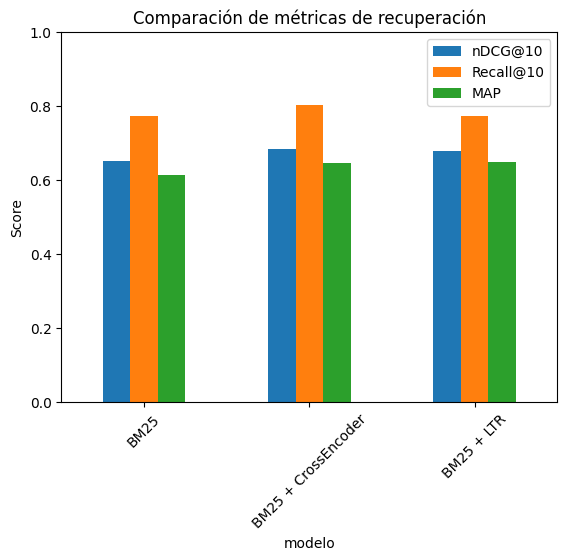

In [46]:
import matplotlib.pyplot as plt

final_results.set_index("modelo")[["nDCG@10", "Recall@10", "MAP"]].plot(kind="bar")

plt.title("Comparación de métricas de recuperación")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

### Comparar cambios finales en una query

### BM25 vs CrossEncoder

In [47]:
compare_top10_general(bm25_results, ce_results_complete, "133", after_name="CrossEncoder")

,doc_id,title,rank_BM25,rank_CrossEncoder,relevance,cambio
0,5270265,Combating trastuzumab resistance by targeting ...,1.0,NaN,0,True
1,26688294,Schizophrenia susceptibility pathway neureguli...,2.0,NaN,0,True
2,19752008,A specific inhibitor of phosphatidylinositol 3...,3.0,6.0,0,True
3,45764440,Inhibition of SRC expression and activity inhi...,4.0,NaN,0,True
4,16280642,Sequential signals toward podosome formation i...,5.0,3.0,1,True
5,12785130,The regulation of N-methyl-D-aspartate recepto...,6.0,NaN,0,True
6,5914739,Local changes in lipid environment of TCR micr...,7.0,10.0,0,True
7,11200685,Integrins regulate microtubule nucleating acti...,8.0,NaN,0,True
8,37964706,Local Ca2+ influx through Ca2+ release-activat...,9.0,9.0,0,False
9,35660758,D3 phosphoinositides and outside-in integrin s...,10.0,1.0,0,True


### BM25 vs LTR

In [48]:
compare_top10_general(bm25_results, ltr_results_complete, "133", after_name="LTR")

,doc_id,title,rank_BM25,rank_LTR,relevance,cambio
0,5270265,Combating trastuzumab resistance by targeting ...,1.0,9.0,0,True
1,26688294,Schizophrenia susceptibility pathway neureguli...,2.0,6.0,0,True
2,19752008,A specific inhibitor of phosphatidylinositol 3...,3.0,1.0,0,True
3,45764440,Inhibition of SRC expression and activity inhi...,4.0,NaN,0,True
4,16280642,Sequential signals toward podosome formation i...,5.0,7.0,1,True
5,12785130,The regulation of N-methyl-D-aspartate recepto...,6.0,2.0,0,True
6,5914739,Local changes in lipid environment of TCR micr...,7.0,10.0,0,True
7,11200685,Integrins regulate microtubule nucleating acti...,8.0,NaN,0,True
8,37964706,Local Ca2+ influx through Ca2+ release-activat...,9.0,NaN,0,True
9,35660758,D3 phosphoinositides and outside-in integrin s...,10.0,3.0,0,True


En este ejercicio se implementó un pipeline de Recuperación de Información en dos etapas. Primero se utilizó BM25 como modelo base para recuperar documentos candidatos. Luego se aplicaron dos técnicas de re-ranking: Cross-Encoder y Learning to Rank.

Al comparar los resultados mediante las métricas nDCG@10, Recall@10 y MAP, se pudo observar el impacto del re-ranking sobre el ranking inicial. El valor de nDCG@10 permite analizar si los documentos relevantes quedaron mejor posicionados en los primeros resultados. Recall@10 indica cuántos documentos relevantes fueron recuperados dentro del top 10, mientras que MAP evalúa la precisión promedio considerando la posición de los documentos relevantes.

A partir de la tabla final, se puede identificar si el Cross-Encoder o el modelo LTR mejoraron el desempeño respecto a BM25. Además, mediante la comparación del top 10 para la query 133, se evidenció qué documentos cambiaron de posición después del re-ranking.